## Lab 2: final challenges

__Вам предлагается решить задачу классификации сигналов или задачу классификации изображений. Или обе ;)__

__Выполнение этих заданий не является обязательным, но позитивно повлияет на вашу итоговую оценку. Успехов!__


### Part 4. HAR classification with raw data (2+ points)
__Disclaimer__: Это опциональная часть задания. Здесь придется экспериментировать, подбирать оптимальную структуру сети для решения задачи и активно искать подскзаки в сети.


Данное задание составлено на основе данного [поста](https://burakhimmetoglu.com/2017/08/22/time-series-classification-with-tensorflow/). С помощью вручную сгенерированных фичей и классических подходов задача распознования движений была решена с точностью 96%.

Также будет полезным изучить [вот этот](https://github.com/healthDataScience/deep-learning-HAR), а так же [вот этот репозиторий](https://github.com/guillaume-chevalier/LSTM-Human-Activity-Recognition), где к данной задаче рассматривается несколько подходов.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import math
import pylab
import warnings as w
import os

%matplotlib inline

In [2]:
import matplotlib
matplotlib.rcParams.update({'font.size':14})

In [3]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


Вернемся к задаче классификации движений на основе [данных](https://archive.ics.uci.edu/ml/datasets/Human+Activity+Recognition+Using+Smartphones) из репозитория UCI ([прямая ссылка на скачивание](https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip)).

В этот раз будем работать с исходными, а не предобработанными данными. Данные представляют собой сигналы с гироскопа и акселерометра, закрепленного на теле человека. Каждому семплу соотвествует 9 связанных временных рядов.

В начале приведена визуализация данных на основе PCA над вручную сгенерированными признаками. Для отрисовки графиков (цвет и легенда) нам также понадобятся метки классов.

In [4]:
import os

# Проверка существования файлов
x_train_path = os.path.join("/content", "gdrive", "MyDrive", "UCI HAR Dataset", "train", "X_train.txt")
y_train_path = os.path.join("/content", "gdrive", "MyDrive", "UCI HAR Dataset", "train", "y_train.txt")

if not os.path.exists(x_train_path):
    raise FileNotFoundError(f"Файл не найден: {x_train_path}")
if not os.path.exists(y_train_path):
    raise FileNotFoundError(f"Файл не найден: {y_train_path}")
print("Файлы найдены, продолжаем.")


Файлы найдены, продолжаем.


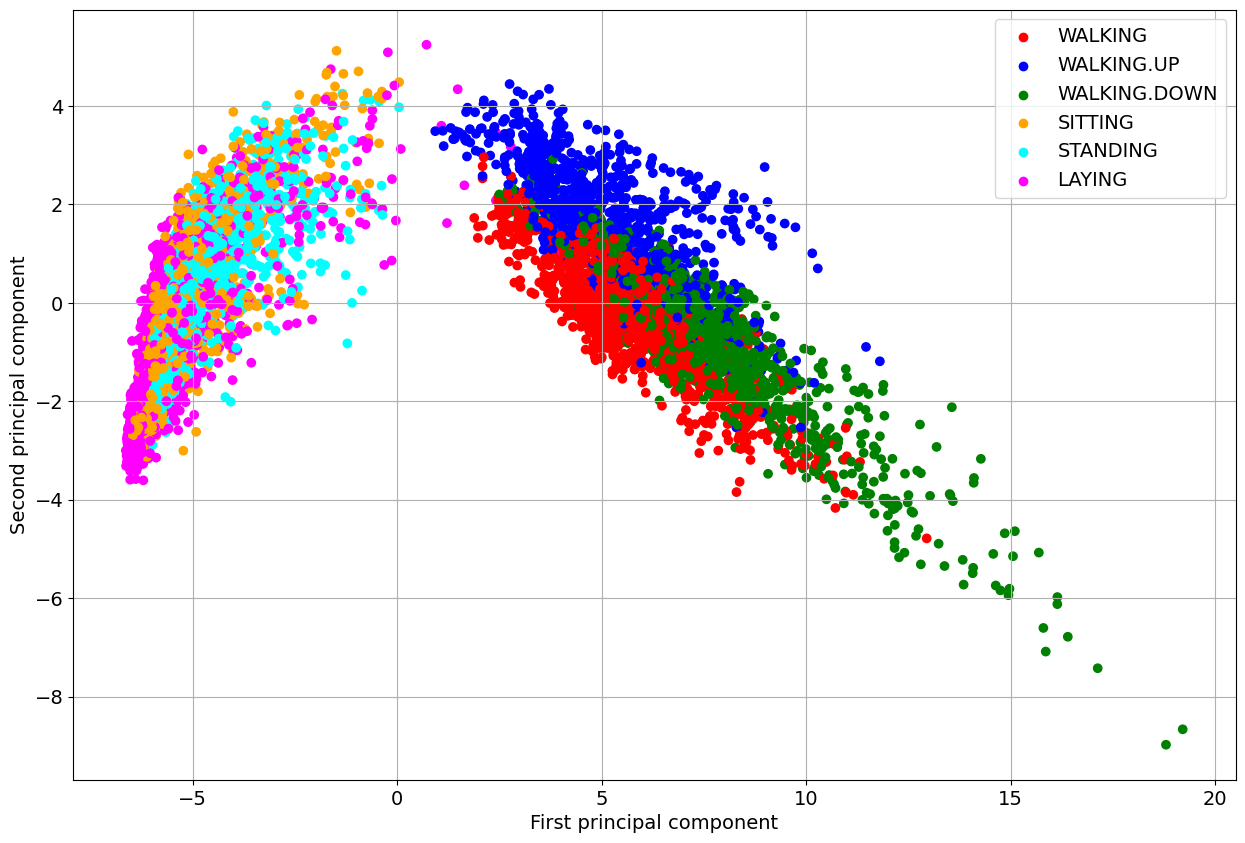

In [36]:
X_train_with_engineered_features = np.genfromtxt(os.path.join("/content", "gdrive", "MyDrive", "UCI HAR Dataset", "train", "X_train.txt"))
y_train = np.genfromtxt(os.path.join("/content", "gdrive", "MyDrive", "UCI HAR Dataset", "train", "y_train.txt"))

y_train_list = list(y_train)
X_unique = np.array([X_train_with_engineered_features[y_train_list.index(l)]
                             for l in sorted(list(set(y_train)))])

legend_labels = ["WALKING", "WALKING.UP", "WALKING.DOWN", "SITTING", "STANDING", "LAYING"]
colors_list = ['red', 'blue', 'green', 'orange', 'cyan', 'magenta']
mapped_colors = [colors_list[int(i)-1] for i in y_train]

from sklearn.decomposition import PCA
pca = PCA()

X_train_pca = pca.fit_transform(X_train_with_engineered_features)

plt.figure(figsize=(15,10))
pylab.scatter(X_train_pca[:, 0], X_train_pca[:, 1],
             c=mapped_colors)
plt.grid()
for idx, x in enumerate(pca.transform(X_unique)):
    plt.scatter(x[0],
                x[1],
                c=colors_list[idx],
                label=legend_labels[idx])
plt.xlabel('First principal component')
plt.ylabel('Second principal component')
plt.legend()

#### Предобработка данных
Предобработка сделана за нас автором [данного репозитория](https://github.com/guillaume-chevalier/LSTM-Human-Activity-Recognition). Будьте осторожны с путями.

In [6]:
signal_path = "/content/gdrive/MyDrive/UCI HAR Dataset/train/Inertial Signals/"

In [54]:
# Useful Constants

# Those are separate normalised input features for the neural network
INPUT_SIGNAL_TYPES = [
    "body_acc_x_",
    "body_acc_y_",
    "body_acc_z_",
    "body_gyro_x_",
    "body_gyro_y_",
    "body_gyro_z_",
    "total_acc_x_",
    "total_acc_y_",
    "total_acc_z_"
]

# Output classes to learn how to classify
LABELS = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"
]

DATA_PATH = "/content/gdrive/MyDrive/"

DATASET_PATH = DATA_PATH + "UCI HAR Dataset/"
print("\n" + "Dataset is now located at: " + DATASET_PATH)

TRAIN = "train/"
TEST = "test/"


# Load "X" (the neural network's training and testing inputs)

def load_X(X_signals_paths):
    X_signals = []

    for signal_type_path in X_signals_paths:
        file = open(signal_type_path, 'r')
        # Read dataset from disk, dealing with text files' syntax
        X_signals.append(
            [np.array(serie, dtype=np.float32) for serie in [
                row.replace('  ', ' ').strip().split(' ') for row in file
            ]]
        )
        file.close()

    return np.transpose(np.array(X_signals), (1, 2, 0))

X_train_signals_paths = [
    os.path.join(*[DATASET_PATH, TRAIN, "Inertial Signals/", signal+"train.txt"]) for signal in INPUT_SIGNAL_TYPES
]
X_test_signals_paths = [
    os.path.join(*[DATASET_PATH, TEST, "Inertial Signals/", signal+"test.txt"]) for signal in INPUT_SIGNAL_TYPES
]

X_train = load_X(X_train_signals_paths)
X_test = load_X(X_test_signals_paths)


# Load "y" (the neural network's training and testing outputs)

def load_y(y_path):
    file = open(y_path, 'r')
    # Read dataset from disk, dealing with text file's syntax
    y_ = np.array(
        [elem for elem in [
            row.replace('  ', ' ').strip().split(' ') for row in file
        ]],
        dtype=np.int32
    )
    file.close()

    # Substract 1 to each output class for friendly 0-based indexing
    return y_ - 1

y_train_path = os.path.join(DATASET_PATH, TRAIN, "y_train.txt")
y_test_path = os.path.join(DATASET_PATH, TEST, "y_test.txt")

y_train = load_y(y_train_path)
y_test = load_y(y_test_path)


Dataset is now located at: /content/gdrive/MyDrive/UCI HAR Dataset/


In [55]:
# Input Data

training_data_count = len(X_train)  # 7352 training series (with 50% overlap between each serie)
test_data_count = len(X_test)  # 2947 testing series
n_steps = len(X_train[0])  # 128 timesteps per series
n_input = len(X_train[0][0])  # 9 input parameters per timestep


# LSTM Neural Network's internal structure

n_hidden = 32 # Hidden layer num of features
n_classes = 6 # Total classes (should go up, or should go down)


# Some debugging info

print("Some useful info to get an insight on dataset's shape and normalisation:")
print("(X shape, y shape, every X's mean, every X's standard deviation)")
print(X_test.shape, y_test.shape, np.mean(X_test), np.std(X_test))
print("The dataset is therefore properly normalised, as expected, but not yet one-hot encoded.")

Some useful info to get an insight on dataset's shape and normalisation:
(X shape, y shape, every X's mean, every X's standard deviation)
(2947, 128, 9) (2947, 1) 0.09913992 0.39567086
The dataset is therefore properly normalised, as expected, but not yet one-hot encoded.


#### Построение сети и эксперименты. (100% +)

__Ваша задача - построить сеть, которая решит задачу классификации с точностью (`accuracy`) не менее 86%.__
Разбалловка следующая:
* $=$86% - 2 points
* $>=$89% - 2.5 points
* $>=$91% - 3 points


__Warning!__ В сети существует несколько решений данной задачи с использованием различных фреймворков. При проверке это будет учитываться, так что свое решение нужно будет объяснить. Пожалуйста, не копируйте бездумно код, такие задания будут оценены 0 баллов. Если задача не решается - можете обратиться к заданию по классификации изображений.

После выполнения задания заполните небольшой отчет об экспериментах вида "Я пробовал(а) ... подходы и получил(а) ... результаты. Наконец, после N+1 чашки кофе/бессонной ночи у меня получилось, и весь секрет был в ..."

In [56]:
# Your experiments here
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split

# One-hot encoding
y_train_one_hot = torch.eye(n_classes)[torch.tensor(y_train).squeeze()]
y_test_one_hot = torch.eye(n_classes)[torch.tensor(y_test).squeeze()]

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train_one_hot, test_size=0.2, random_state=42)

X_train, y_train = torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.float32)
X_val, y_val = torch.tensor(X_val, dtype=torch.float32), torch.tensor(y_val, dtype=torch.float32)
X_test, y_test = torch.tensor(X_test, dtype=torch.float32), torch.tensor(y_test_one_hot, dtype=torch.float32)


# class LSTMModel(nn.Module):
#     def __init__(self, input_size, hidden_size, num_classes):
#         super(LSTMModel, self).__init__()
#         self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
#         self.fc = nn.Linear(hidden_size, num_classes)

#     def forward(self, x):
#         h_lstm, _ = self.lstm(x)
#         h_last = h_lstm[:, -1, :]  # Take the output of the last time step
#         out = self.fc(h_last)
#         return out


# model = LSTMModel(n_input, n_hidden, n_classes)


class LSTMModelWithBN(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes, dropout_rate=0.5):
        super(LSTMModelWithBN, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_classes)
        self.bn = nn.BatchNorm1d(hidden_size)  # BatchNorm для выхода LSTM
        self.dropout = nn.Dropout(dropout_rate)  # Dropout для регуляризации

    def forward(self, x):
        h_lstm, _ = self.lstm(x)
        h_last = h_lstm[:, -1, :]  # Последний шаг
        h_last = self.bn(h_last)  # BatchNorm
        h_last = self.dropout(h_last)  # Dropout
        out = self.fc(h_last)  # Линейный слой
        return out


model = LSTMModelWithBN(input_size=n_input, hidden_size=n_hidden, num_classes=n_classes)
loss_func = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)#, weight_decay=1e-4)

# Параметры для уменьшения learning rate
#scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5, verbose=True)

num_epochs = 30
batch_size = 64

val_losses = []
val_accuracies = []

for epoch in range(num_epochs):
    model.train()
    for i in range(0, len(X_train), batch_size):
        X_batch = X_train[i:i+batch_size]
        y_batch = y_train[i:i+batch_size]

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = loss_func(outputs, torch.argmax(y_batch, dim=1))
        loss.backward()
        optimizer.step()

    # Evaluate on validation set
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val)
        val_loss = loss_func(val_outputs, torch.argmax(y_val, dim=1))
        val_acc = (torch.argmax(val_outputs, dim=1) == torch.argmax(y_val, dim=1)).float().mean()
        val_losses.append(val_loss.item())

        # Вычисление точности
        _, predicted = torch.max(val_outputs, 1)
        _, labels = torch.max(y_val, 1)
        accuracy = (predicted == labels).float().mean().item()
        val_accuracies.append(accuracy)
    print(f"Epoch {epoch}/{num_epochs}, Validation Loss: {val_loss.item():.4f}, Validation Accuracy: {accuracy:.4f}")

    # Обновление learning rate
    #scheduler.step(val_loss)  # Передаем validation loss для обновления learning rate

# Test the model
model.eval()
with torch.no_grad():
    test_outputs = model(X_test)
    test_acc = (torch.argmax(test_outputs, dim=1) == torch.argmax(y_test, dim=1)).float().mean()
print(f"Test Accuracy: {test_acc:.4f}")



<ipython-input-56-aa08e0b2997d>:13: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_train, y_train = torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.float32)
<ipython-input-56-aa08e0b2997d>:14: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_val, y_val = torch.tensor(X_val, dtype=torch.float32), torch.tensor(y_val, dtype=torch.float32)
<ipython-input-56-aa08e0b2997d>:15: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_test, y_test = torch.tensor(X_test, dtype=torch.float32), torch.tensor(y_test_one_hot, dtype

Epoch 0/30, Validation Loss: 0.9729, Validation Accuracy: 0.6105
Epoch 1/30, Validation Loss: 0.6590, Validation Accuracy: 0.7220
Epoch 2/30, Validation Loss: 0.6002, Validation Accuracy: 0.7716
Epoch 3/30, Validation Loss: 0.5376, Validation Accuracy: 0.8165
Epoch 4/30, Validation Loss: 0.4421, Validation Accuracy: 0.8375
Epoch 5/30, Validation Loss: 0.3526, Validation Accuracy: 0.8627
Epoch 6/30, Validation Loss: 0.3329, Validation Accuracy: 0.8749
Epoch 7/30, Validation Loss: 0.3224, Validation Accuracy: 0.8838
Epoch 8/30, Validation Loss: 0.2739, Validation Accuracy: 0.8926
Epoch 9/30, Validation Loss: 0.3309, Validation Accuracy: 0.8899
Epoch 10/30, Validation Loss: 0.4966, Validation Accuracy: 0.7403
Epoch 11/30, Validation Loss: 0.1634, Validation Accuracy: 0.9354
Epoch 12/30, Validation Loss: 0.1899, Validation Accuracy: 0.9150
Epoch 13/30, Validation Loss: 0.1892, Validation Accuracy: 0.9327
Epoch 14/30, Validation Loss: 0.1624, Validation Accuracy: 0.9429
Epoch 15/30, Validat

Для повышения точности модели пришлось бороться с переобучением, для этого уменьшалось количество эпох с 50 до 30, добавились методы Dropout и BatchNormalozation, изменялась learning rate, как само значение, так и динамический подход ReduceLROnPlateau. Наиболее эффективными оказались метод ранней остановхе (редукция количества эпох до 30) и комбинация Dropout и BatchNormalozation.

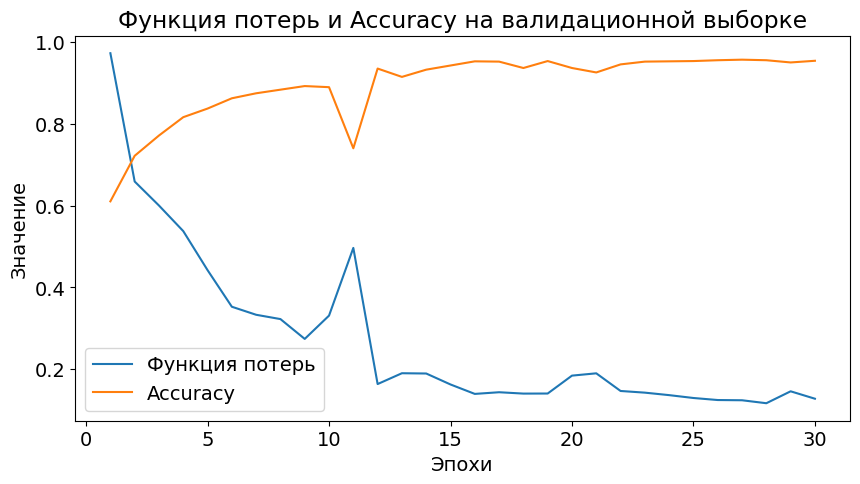

In [59]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(range(1, num_epochs+1), val_losses, label='Функция потерь')
plt.plot(range(1, num_epochs+1), val_accuracies, label='Accuracy')
plt.xlabel('Эпохи')
plt.ylabel('Значение')
plt.title('Функция потерь и Accuracy на валидационной выборке')
plt.legend()
plt.show()


### Part 5. Dogs classification (2+ points)
__Disclaimer__: Это опциональная часть задания. Здесь придется экспериментировать, подбирать оптимальную структуру сети для решения задачи и активно искать подскзаки в сети.

Предлагаем вам решить задачу классификации пород собак. Вы можете обучить сеть с нуля или же воспользоваться методом fine-tuning'а. Полезная ссылка на [предобученные модели](https://pytorch.org/docs/stable/torchvision/models.html).

Данные можно скачать [отсюда](https://www.dropbox.com/s/vgqpz2f1lolxmlv/data.zip?dl=0). Датасет представлен 50 классами пород собак, которые можно найти в папке train в соответствующих директориях. При сдаче данной части задания вместе с ноутбуком необходимо отправить .csv-файл с предсказаниями классов тестовой выборки в формате: <имя изображения>,<метка класса> по одному объекту на строку. Ниже приведите код ваших экспериментов и короткий вывод по их результатам.

Будут оцениваться качество классификации (accuracy) на тестовой выборке (2 балла) и проведенные эксперименты (1 балл).
Разбалловка следующая:
* $>=$93% - 2 points
* $>=$84% - 1.5 points
* $>=$70% - 0.75 points

In [3]:
!pip install torchvision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 2.6 MB/s eta 0:00:0000:0100:01

[notice] A new release of pip is available: 23.3.2 -> 24.3.1
[notice] To update, run: pip install --upgrade pip


В связи с ограниченными вычислительными ресурсами была выбрана для экспериментов по файнтьюнингу самая "маленькая" предобученная нейронная сеть ResNet18. В ней был заменен последний слой на полносвязный слой с количеством нейронов, равным количеству классов (50 в нашем случае). Ранние слои были заморожены и разморожен только последний слой. Также был использован "планировщик" для планового уменьшения learning rate. Ниже представлен результат.


Epoch [1/10], Step [10/180], Loss: 2.6072, Accuracy: 0.1969
Epoch [1/10], Step [20/180], Loss: 1.7470, Accuracy: 0.3172
Epoch [1/10], Step [30/180], Loss: 1.4718, Accuracy: 0.3990
Epoch [1/10], Step [40/180], Loss: 1.3443, Accuracy: 0.4633
Epoch [1/10], Step [50/180], Loss: 1.4122, Accuracy: 0.5025
Epoch [1/10], Step [60/180], Loss: 1.2394, Accuracy: 0.5271
Epoch [1/10], Step [70/180], Loss: 1.0885, Accuracy: 0.5478
Epoch [1/10], Step [80/180], Loss: 1.3153, Accuracy: 0.5648
Epoch [1/10], Step [90/180], Loss: 0.9905, Accuracy: 0.5767
Epoch [1/10], Step [100/180], Loss: 0.8990, Accuracy: 0.5881
Epoch [1/10], Step [110/180], Loss: 0.8683, Accuracy: 0.5955
Epoch [1/10], Step [120/180], Loss: 1.2330, Accuracy: 0.6026
Epoch [1/10], Step [130/180], Loss: 1.2196, Accuracy: 0.6099
Epoch [1/10], Step [140/180], Loss: 0.9354, Accuracy: 0.6183
Epoch [1/10], Step [150/180], Loss: 0.9966, Accuracy: 0.6250
Epoch [1/10], Step [160/180], Loss: 1.0815, Accuracy: 0.6311
Epoch [1/10], Step [170/180], Los

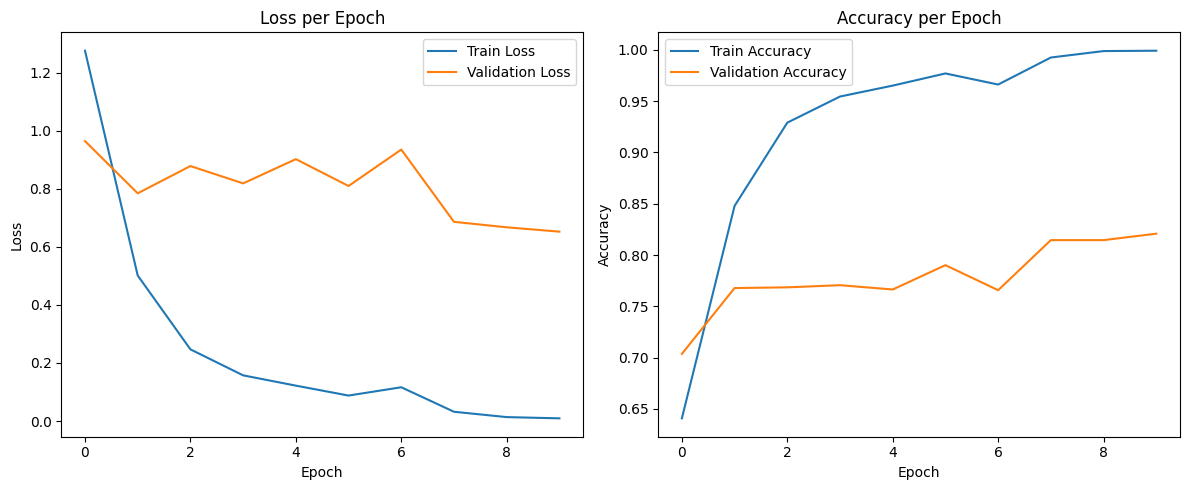

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from torch.utils.data import DataLoader, random_split
from torchvision.datasets import ImageFolder
from torch.optim import lr_scheduler
import matplotlib.pyplot as plt

num_classes = 50
batch_size = 32
num_epochs = 10
learning_rate = 0.001
local_model_path = 'resnet18-5c106cde.pth'  

# Трансформации данных
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

full_train_dataset = ImageFolder('/Users/annaportyanko/Downloads/data/train', transform=transform)

# Разделение на train и validation (80/20)
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# Загрузка ResNet18
model = models.resnet18()
model.load_state_dict(torch.load(local_model_path))

# Заморозка ранних слоёв
for param in model.parameters():
    param.requires_grad = False

# Разморозка только последнего слоя
for param in model.layer4.parameters():
    param.requires_grad = True
model.fc = nn.Linear(model.fc.in_features, num_classes)  # Новый полносвязный слой

# Перевод модели на GPU, если доступно
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=learning_rate)

# Планировщик обучения
scheduler = lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct, total = 0, 0
    for i, (inputs, labels) in enumerate(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        # Accuracy
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        # Лог каждые 10 шагов
        if (i + 1) % 10 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{len(train_loader)}], Loss: {loss.item():.4f}, Accuracy: {correct / total:.4f}')

    train_loss = running_loss / len(train_loader)
    train_accuracy = correct / total
    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)
    print(f'Epoch [{epoch+1}/{num_epochs}] Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.4f}')

    model.eval()
    val_loss = 0.0
    correct, total = 0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            # Accuracy
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_loss /= len(val_loader)
    val_accuracy = correct / total
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)
    print(f'Epoch [{epoch+1}/{num_epochs}] Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_accuracy:.4f}')

    scheduler.step()

torch.save(model.state_dict(), 'dog_breed_classifier_resnet18.pth')

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.title('Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


Как видно, модель демонстрирует ярко выраженное переобучение. Попробуем разморозить параметры в слоях layer3 и layer4.

Epoch [1/10], Step [10/180], Loss: 3.5440, Accuracy: 0.2594
Epoch [1/10], Step [20/180], Loss: 2.2467, Accuracy: 0.2906
Epoch [1/10], Step [30/180], Loss: 1.8234, Accuracy: 0.3375
Epoch [1/10], Step [40/180], Loss: 1.4114, Accuracy: 0.3883
Epoch [1/10], Step [50/180], Loss: 1.8276, Accuracy: 0.4163
Epoch [1/10], Step [60/180], Loss: 1.8474, Accuracy: 0.4344
Epoch [1/10], Step [70/180], Loss: 1.3260, Accuracy: 0.4437
Epoch [1/10], Step [80/180], Loss: 2.0073, Accuracy: 0.4551
Epoch [1/10], Step [90/180], Loss: 1.0751, Accuracy: 0.4736
Epoch [1/10], Step [100/180], Loss: 1.2316, Accuracy: 0.4878
Epoch [1/10], Step [110/180], Loss: 1.2104, Accuracy: 0.4972
Epoch [1/10], Step [120/180], Loss: 1.0037, Accuracy: 0.5089
Epoch [1/10], Step [130/180], Loss: 1.3262, Accuracy: 0.5202
Epoch [1/10], Step [140/180], Loss: 0.9666, Accuracy: 0.5268
Epoch [1/10], Step [150/180], Loss: 1.0663, Accuracy: 0.5331
Epoch [1/10], Step [160/180], Loss: 1.1458, Accuracy: 0.5379
Epoch [1/10], Step [170/180], Los

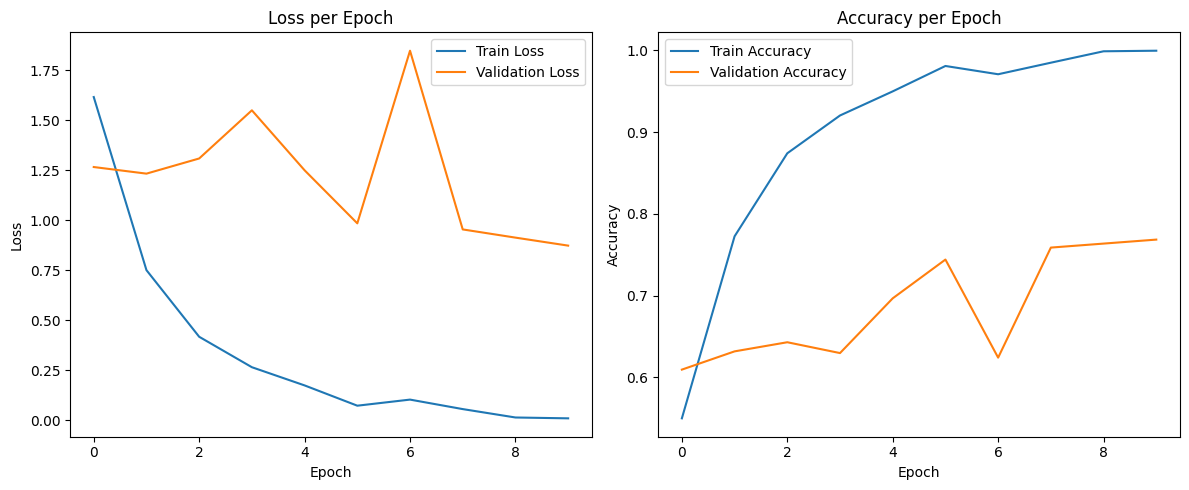

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from torch.utils.data import DataLoader, random_split
from torchvision.datasets import ImageFolder
from torch.optim import lr_scheduler
import matplotlib.pyplot as plt

num_classes = 50
batch_size = 32
num_epochs = 10
learning_rate = 0.001
local_model_path = 'resnet18-5c106cde.pth'  

transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

full_train_dataset = ImageFolder('/Users/annaportyanko/Downloads/data/train', transform=transform)

# Разделение на train и validation (80/20)
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

model = models.resnet18()
model.load_state_dict(torch.load(local_model_path))

# Заморозка ранних слоёв
for param in model.parameters():
    param.requires_grad = False

# Размораживаем слои layer3 и layer4
for param in model.layer3.parameters():
    param.requires_grad = True

for param in model.layer4.parameters():
    param.requires_grad = True

# Замена последнего слоя
model.fc = nn.Linear(model.fc.in_features, 50) 

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=learning_rate)

scheduler = lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct, total = 0, 0
    for i, (inputs, labels) in enumerate(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        # Accuracy
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        # Лог каждые 10 шагов
        if (i + 1) % 10 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{len(train_loader)}], Loss: {loss.item():.4f}, Accuracy: {correct / total:.4f}')

    train_loss = running_loss / len(train_loader)
    train_accuracy = correct / total
    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)
    print(f'Epoch [{epoch+1}/{num_epochs}] Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.4f}')

    model.eval()
    val_loss = 0.0
    correct, total = 0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            # Accuracy
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_loss /= len(val_loader)
    val_accuracy = correct / total
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)
    print(f'Epoch [{epoch+1}/{num_epochs}] Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_accuracy:.4f}')

    scheduler.step()

torch.save(model.state_dict(), 'dog_breed_classifier_resnet18.pth')

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.title('Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


Модель все еще переобучается, метрики качества ухудшились.
Добавлена аугментация для обучающего набора данных: случайная обрезка, случайное горизонтальное отражение, изменение яркости и контраста и случайный поворот. Разморожен только последний слой.

Epoch [1/10], Step [10/180], Loss: 3.8870, Accuracy: 0.0563
Epoch [1/10], Step [20/180], Loss: 3.0872, Accuracy: 0.1047
Epoch [1/10], Step [30/180], Loss: 2.7888, Accuracy: 0.1625
Epoch [1/10], Step [40/180], Loss: 2.6260, Accuracy: 0.2195
Epoch [1/10], Step [50/180], Loss: 2.3902, Accuracy: 0.2769
Epoch [1/10], Step [60/180], Loss: 2.3041, Accuracy: 0.3312
Epoch [1/10], Step [70/180], Loss: 2.0936, Accuracy: 0.3759
Epoch [1/10], Step [80/180], Loss: 1.4331, Accuracy: 0.4094
Epoch [1/10], Step [90/180], Loss: 1.6011, Accuracy: 0.4378
Epoch [1/10], Step [100/180], Loss: 1.2598, Accuracy: 0.4703
Epoch [1/10], Step [110/180], Loss: 1.3023, Accuracy: 0.4929
Epoch [1/10], Step [120/180], Loss: 1.4676, Accuracy: 0.5138
Epoch [1/10], Step [130/180], Loss: 0.9736, Accuracy: 0.5351
Epoch [1/10], Step [140/180], Loss: 1.1137, Accuracy: 0.5538
Epoch [1/10], Step [150/180], Loss: 0.9616, Accuracy: 0.5708
Epoch [1/10], Step [160/180], Loss: 1.2318, Accuracy: 0.5809
Epoch [1/10], Step [170/180], Los

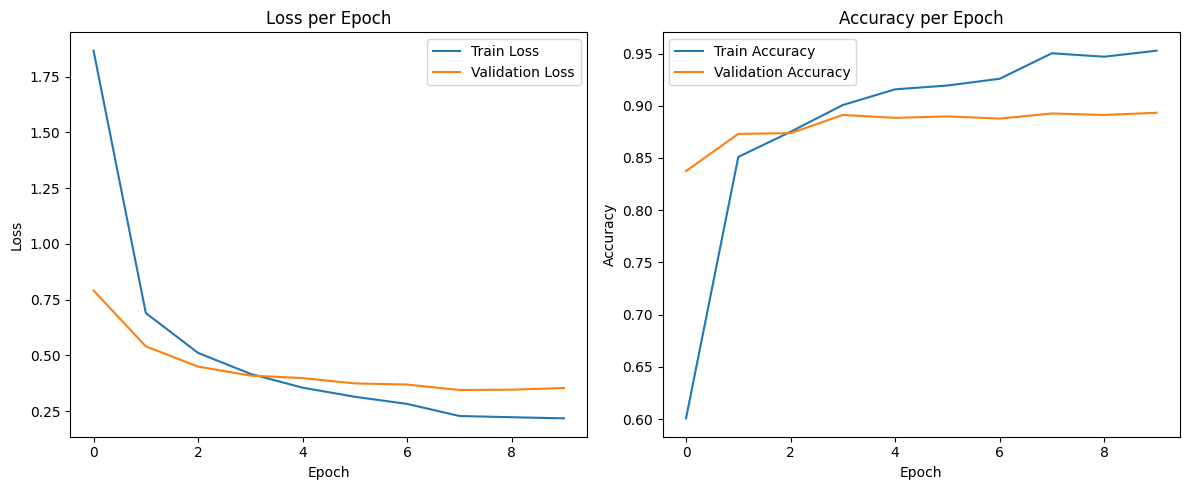

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from torch.utils.data import DataLoader, random_split
from torchvision.datasets import ImageFolder
from torch.optim import lr_scheduler
import matplotlib.pyplot as plt

# Параметры
num_classes = 50
batch_size = 32
num_epochs = 10
learning_rate = 0.001
local_model_path = 'resnet18-5c106cde.pth'  

# Трансформации для данных
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),      # Случайная обрезка и изменение размера
    transforms.RandomHorizontalFlip(),       # Случайное горизонтальное отражение
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),  # Изменение яркости, контраста, насыщенности
    transforms.RandomRotation(20),           # Случайный поворот
    transforms.ToTensor(),                   # Преобразование в тензор
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # Нормализация
])

# Трансформации для валидации (без случайных изменений)
val_transform = transforms.Compose([
    transforms.Resize(256),                 # Изменение размера
    transforms.CenterCrop(224),             # Центрированная обрезка
    transforms.ToTensor(),                  # Преобразование в тензор
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # Нормализация
])

full_train_dataset = ImageFolder('/Users/annaportyanko/Downloads/data/train', transform=train_transform)

# Разделение на train и validation (80/20)
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

val_dataset.dataset.transform = val_transform

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# Загрузка ResNet18
model = models.resnet18()
model.load_state_dict(torch.load(local_model_path))

# Заморозка всех слоев модели
for param in model.parameters():
    param.requires_grad = False

# Размораживаем только последний слой
for param in model.fc.parameters():
    param.requires_grad = True

# Замена последнего слоя для нашей задачи
model.fc = nn.Linear(model.fc.in_features, 50) 

# Перевод модели на GPU, если доступно
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=learning_rate)

# Планировщик обучения
scheduler = lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct, total = 0, 0
    for i, (inputs, labels) in enumerate(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        # Accuracy
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        # Лог каждые 10 шагов
        if (i + 1) % 10 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{len(train_loader)}], Loss: {loss.item():.4f}, Accuracy: {correct / total:.4f}')

    train_loss = running_loss / len(train_loader)
    train_accuracy = correct / total
    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)
    print(f'Epoch [{epoch+1}/{num_epochs}] Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.4f}')

    model.eval()
    val_loss = 0.0
    correct, total = 0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            # Accuracy
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_loss /= len(val_loader)
    val_accuracy = correct / total
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)
    print(f'Epoch [{epoch+1}/{num_epochs}] Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_accuracy:.4f}')

    scheduler.step()

# Сохранение модели
torch.save(model.state_dict(), 'dog_breed_classifier_resnet18.pth')

# Визуализация метрик
plt.figure(figsize=(12, 5))

# График Loss
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# График Accuracy
plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.title('Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


Модель демонстрирует меньшую склонность к переобучению и метрики качества более-менее удовлетворительны для такой простой модели (89%)


In [2]:
import os
from PIL import Image
import pandas as pd
test_data_path = '/Users/annaportyanko/Downloads/data/test'
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Генерация предсказаний для тестовой выборки
def generate_predictions(model, test_data_path, output_csv):
    model.eval()
    test_transform = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    test_images = []
    test_filenames = []

    for file_name in os.listdir(test_data_path):
        if file_name.endswith(('.jpg', '.png', '.jpeg')):
            img_path = os.path.join(test_data_path, file_name)
            image = Image.open(img_path).convert('RGB')
            image = test_transform(image)
            test_images.append(image)
            test_filenames.append(file_name)

    test_images = torch.stack(test_images).to(device)
    predictions = []

    with torch.no_grad():
        outputs = model(test_images)
        _, predicted = outputs.max(1)
        predictions = predicted.cpu().numpy()

    df = pd.DataFrame({'filename': test_filenames, 'label': predictions})
    df.to_csv(output_csv, index=False)

# Сохранение предсказаний
output_csv_path = 'test_predictions.csv'
generate_predictions(model, test_data_path, output_csv_path)
print(f'Predictions saved to {output_csv_path}')


Predictions saved to test_predictions.csv


Попробуем побороть переобучение, которое все еще присутсвует, добавлением BatchNorm и Dropout

Epoch [1/10], Step [10/180], Loss: 4.9890, Accuracy: 0.0875
Epoch [1/10], Step [20/180], Loss: 3.4164, Accuracy: 0.1109
Epoch [1/10], Step [30/180], Loss: 2.8408, Accuracy: 0.1250
Epoch [1/10], Step [40/180], Loss: 2.8189, Accuracy: 0.1539
Epoch [1/10], Step [50/180], Loss: 2.8231, Accuracy: 0.1800
Epoch [1/10], Step [60/180], Loss: 2.5450, Accuracy: 0.2042
Epoch [1/10], Step [70/180], Loss: 2.3035, Accuracy: 0.2165
Epoch [1/10], Step [80/180], Loss: 2.2820, Accuracy: 0.2344
Epoch [1/10], Step [90/180], Loss: 1.8927, Accuracy: 0.2503
Epoch [1/10], Step [100/180], Loss: 2.0340, Accuracy: 0.2622
Epoch [1/10], Step [110/180], Loss: 1.6727, Accuracy: 0.2764
Epoch [1/10], Step [120/180], Loss: 1.6374, Accuracy: 0.2880
Epoch [1/10], Step [130/180], Loss: 1.8719, Accuracy: 0.2971
Epoch [1/10], Step [140/180], Loss: 1.9191, Accuracy: 0.3092
Epoch [1/10], Step [150/180], Loss: 1.6754, Accuracy: 0.3194
Epoch [1/10], Step [160/180], Loss: 1.4938, Accuracy: 0.3322
Epoch [1/10], Step [170/180], Los

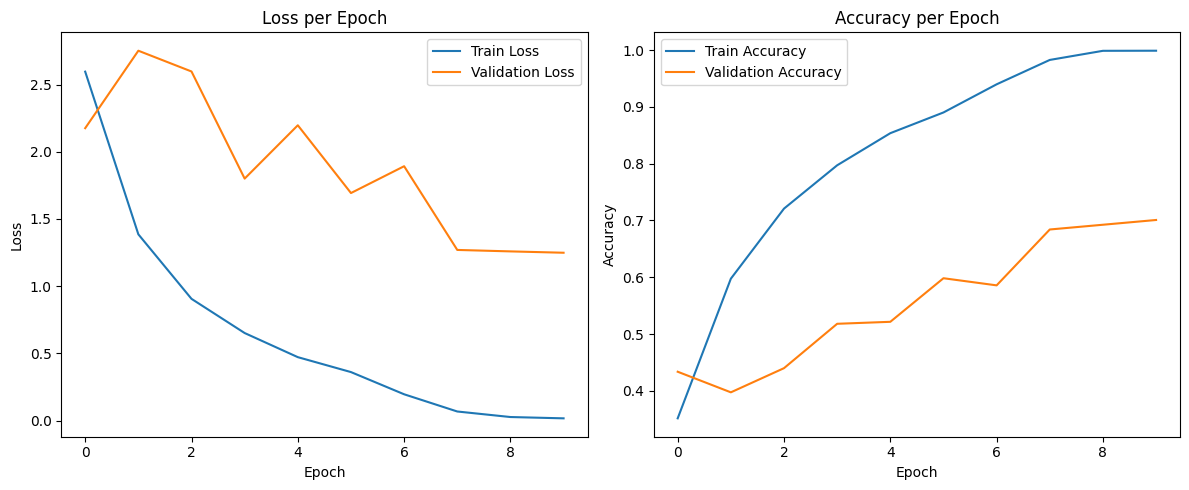

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from torch.utils.data import DataLoader, random_split
from torchvision.datasets import ImageFolder
from torch.optim import lr_scheduler
import matplotlib.pyplot as plt

# Определение кастомной модели с BatchNorm и Dropout
class ResNet18Custom(nn.Module):
    def __init__(self, pretrained_model, num_classes):
        super(ResNet18Custom, self).__init__()
        self.features = nn.Sequential(*list(pretrained_model.children())[:-1])  # Все слои, кроме последнего fc
        self.fc = nn.Sequential(
            nn.BatchNorm1d(pretrained_model.fc.in_features),  # BatchNorm на входах к Linear
            nn.Dropout(0.5),  # Dropout с вероятностью 0.5
            nn.Linear(pretrained_model.fc.in_features, num_classes)  # Последний слой
        )
    
    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x

num_classes = 50
batch_size = 32
num_epochs = 10
learning_rate = 0.001
local_model_path = 'resnet18-5c106cde.pth' 

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),      # Случайная обрезка и изменение размера
    transforms.RandomHorizontalFlip(),       # Случайное горизонтальное отражение
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),  # Изменение яркости, контраста, насыщенности
    transforms.RandomRotation(20),           # Случайный поворот
    transforms.ToTensor(),                   # Преобразование в тензор
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # Нормализация
])

# Трансформации для валидации (без случайных изменений)
val_transform = transforms.Compose([
    transforms.Resize(256),                 # Изменение размера
    transforms.CenterCrop(224),             # Центрированная обрезка
    transforms.ToTensor(),                  # Преобразование в тензор
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # Нормализация
])

full_train_dataset = ImageFolder('/Users/annaportyanko/Downloads/data/train', transform=train_transform)

# Разделение на train и validation (80/20)
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

# Применяем трансформации для валидации
val_dataset.dataset.transform = val_transform

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# Загрузка ResNet18
model = models.resnet18()
model.load_state_dict(torch.load(local_model_path))

# Создание кастомной модели
custom_model = ResNet18Custom(model, num_classes=num_classes)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
custom_model= model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=learning_rate)

# Планировщик обучения
scheduler = lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

for epoch in range(num_epochs):
    custom_model.train()
    running_loss = 0.0
    correct, total = 0, 0
    for i, (inputs, labels) in enumerate(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = custom_model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        # Accuracy
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        # Лог каждые 10 шагов
        if (i + 1) % 10 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{len(train_loader)}], Loss: {loss.item():.4f}, Accuracy: {correct / total:.4f}')

    train_loss = running_loss / len(train_loader)
    train_accuracy = correct / total
    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)
    print(f'Epoch [{epoch+1}/{num_epochs}] Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.4f}')

    model.eval()
    val_loss = 0.0
    correct, total = 0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            # Accuracy
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_loss /= len(val_loader)
    val_accuracy = correct / total
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)
    print(f'Epoch [{epoch+1}/{num_epochs}] Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_accuracy:.4f}')

    scheduler.step()

torch.save(custom_model.state_dict(), 'dog_breed_classifier_resnet18_custom.pth')

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.title('Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


Видно, что добавление BatchNorm и Dropout только усугубило ситуацию.
Также была опробована более сложная модель ResNet50 (результаты не представлены в данном ноутбуке и могут быть представлены дополнительно). Были применены все те же подходы, которые использовались в самом успешном варианте с ResNet18 (аугментация данных, заморозка всех слоев кроме последнего, замена последнего в соответсвии с нашим количеством классов). Однако, вероятно ResNet50 слишком сложная для такого относительно небольшого датасета. Ее точность составила 71%. 

Таким образом, можно сделать вывод о том, что файнтьюнинг - сложный и малопредсказуемый процесс. Важно пробовать различные варианты сетей и варианты их настройки, заранее предсказать, что именно приведет к успеху, сложно.

Важно соотношение сложности сети и объема данных, в определенной ситуации маленькая нейронная сеть может себя показать лучше сложной. Как в данном случае, когда наилучшие результаты на валидационной выборке показала ResNet18 (89%).